# 🧠 Laboratorio 3 — Redes Neuronales Artificiales con TensorFlow

**Curso:** Inteligencia Artificial — Nivel Intermedio  
**Sesión:** #3 | **Duración:** 2 horas  
**Institución:** Universidad Libre / Talento Tech

---

## Objetivos

1. Implementar un **perceptrón simple** en Python para comprender pesos y sesgos.
2. Desarrollar una **red neuronal multicapa** con Keras.
3. Aplicar redes neuronales para **clasificación de imágenes** con el dataset MNIST.
4. **Evaluar y ajustar** hiperparámetros para mejorar la precisión del modelo.

---

## Requisitos

```bash
pip install numpy pandas matplotlib scikit-learn tensorflow
```

---

## Estructura del laboratorio

| # | Sección | Tiempo |
|---|---------|--------|
| 1 | Perceptrón simple | 20 min |
| 2 | Red Neuronal Multicapa | 30 min |
| 3 | Clasificación MNIST | 40 min |
| 4 | Ajuste de hiperparámetros | 20 min |

---
# Sección 1 — Introducción al Perceptrón (20 min)

## Concepto

El **perceptrón** es la unidad básica de las redes neuronales. Recibe entradas, les asigna un **peso** (importancia), suma todo junto a un **sesgo** (bias), y decide si activarse o no mediante una **función de activación**.

```
salida = f(w1·x1 + w2·x2 + ... + wn·xn + b)
```

- **Pesos (w):** determinan la importancia de cada entrada
- **Sesgo (b):** desplaza el umbral de decisión
- **Función escalón:** retorna 1 si la suma supera el umbral, 0 si no

---
## Ejemplo Práctico 1 — Decisión de viajar (Perceptrón Interactivo)

Un perceptrón evalúa 3 factores binarios para decidir si viajar:
- 💰 Dinero disponible
- 💑 Opinión positiva de la pareja  
- ☀️ Buen clima

In [1]:
# ─────────────────────────────────────────────────────────
# EJEMPLO PRÁCTICO 1: Perceptrón interactivo — ¿Viajar o no?
# Correcciones aplicadas:
#   - Agregado 'import numpy as np' (faltaba en el original)
#   - Agregado 'from ipywidgets import interactive' (faltaba en el original)
# ─────────────────────────────────────────────────────────

import numpy as np
import ipywidgets as widgets
from ipywidgets import interactive   
from IPython.display import display, HTML


def activation_function(x, threshold):
    """
    Función de activación tipo escalón (step function).
    Retorna 1 si la entrada supera el umbral, 0 en caso contrario.
    
    Args:
        x (float): valor de entrada (suma ponderada + sesgo)
        threshold (float): umbral de activación
    Returns:
        int: 1 (activa) o 0 (no activa)
    """
    return 1 if x > threshold else 0


def perceptron_predict(X, W, b, threshold):
    """
    Realiza predicciones para un conjunto de muestras usando el perceptrón.
    Para cada muestra calcula: dot(x, W) + b, luego aplica la función escalón.
    
    Args:
        X (np.array): matriz de entradas, shape (n_samples, n_features)
        W (np.array): vector de pesos, shape (n_features,)
        b (float): sesgo (bias)
        threshold (float): umbral de activación
    Returns:
        list: lista de predicciones (0 o 1) para cada muestra
    """
    return [activation_function(np.dot(x, W) + b, threshold) for x in X]


def interact_perceptron(dinero, opinion_pareja, clima, w1, w2, w3, bias, threshold):
    """
    Función principal del widget interactivo.
    Construye la entrada, ejecuta el perceptrón y muestra el resultado en HTML.
    """
    # Construir vector de entrada a partir de los checkboxes
    X = np.array([[dinero, opinion_pareja, clima]])
    
    # Construir vector de pesos desde los sliders
    W = np.array([w1, w2, w3])
    
    # Ejecutar predicción del perceptrón
    b = bias
    predicciones = perceptron_predict(X, W, b, threshold)

    # Mostrar resultado con formato HTML coloreado
    output = f"""
    <div style="background-color: #f0f0f0; padding: 10px; border-radius: 5px;">
        <h3>Entradas:</h3>
        <ul>
            <li>Dinero: {'Sí' if dinero else 'No'}</li>
            <li>Opinión de la pareja: {'Positiva' if opinion_pareja else 'Negativa'}</li>
            <li>Clima: {'Bueno' if clima else 'Malo'}</li>
        </ul>
        <h3>Parámetros del modelo:</h3>
        <ul>
            <li>Peso Dinero: {w1}</li>
            <li>Peso Opinión: {w2}</li>
            <li>Peso Clima: {w3}</li>
            <li>Sesgo: {bias}</li>
            <li>Umbral: {threshold}</li>
        </ul>
        <h3 style="color: {'green' if predicciones[0] == 1 else 'red'}">
            Predicción (¿Viajar?): {'✅ Sí' if predicciones[0] == 1 else '❌ No'}
        </h3>
    </div>
    """
    display(HTML(output))


# ── Widgets de entrada: checkboxes para los factores binarios ──
dinero_widget       = widgets.Checkbox(description='Dinero suficiente',          value=True)
opinion_widget      = widgets.Checkbox(description='Opinión positiva de la pareja', value=True)
clima_widget        = widgets.Checkbox(description='Buen clima',                 value=True)

# ── Widgets de parámetros: sliders para pesos, sesgo y umbral ──
w1_slider        = widgets.IntSlider(min=-5, max=5, step=1, value=1,   description='Peso Dinero')
w2_slider        = widgets.IntSlider(min=-5, max=5, step=1, value=1,   description='Peso Opinión')
w3_slider        = widgets.IntSlider(min=-5, max=5, step=1, value=1,   description='Peso Clima')
bias_slider      = widgets.IntSlider(min=-5, max=5, step=1, value=0,   description='Sesgo')
threshold_slider = widgets.FloatSlider(min=0, max=5, step=0.1, value=0.5, description='Umbral')

# ── Crear y mostrar la interfaz interactiva ──
interactive(
    interact_perceptron,
    dinero=dinero_widget,
    opinion_pareja=opinion_widget,
    clima=clima_widget,
    w1=w1_slider,
    w2=w2_slider,
    w3=w3_slider,
    bias=bias_slider,
    threshold=threshold_slider
)

interactive(children=(Checkbox(value=True, description='Dinero suficiente'), Checkbox(value=True, description=…

### 📖 Guía de uso del widget

| Control | Rango | Efecto |
|---------|-------|--------|
| Checkboxes (Dinero, Opinión, Clima) | ✓ / ✗ | Activa/desactiva el factor |
| Pesos (w1, w2, w3) | -5 a 5 | Positivo = favorece el viaje; Negativo = lo desfavorece |
| Sesgo | -5 a 5 | Positivo = más tendencia a "Sí"; Negativo = más "No" |
| Umbral | 0 a 5 | Bajo = más fácil obtener "Sí"; Alto = más difícil |

> **¿Cómo funciona?** El perceptrón calcula `w1·dinero + w2·opinión + w3·clima + sesgo` y compara con el umbral.

---
## Ejemplo Práctico 2 — Clasificación de puntos (compuerta AND)

Implementamos un perceptrón que clasifica puntos en un plano 2D.  
Los datos representan la **tabla de verdad de la compuerta AND**:

| x1 | x2 | y |
|----|----|-|
| 0  | 0  | 0 |
| 0  | 1  | 0 |
| 1  | 0  | 0 |
| 1  | 1  | 1 |

> **🎯 Reto:** Ajusta manualmente los valores de `W` y `b` al final del bloque para que el perceptrón clasifique correctamente los 4 puntos.

In [2]:
# ─────────────────────────────────────────────────────────
# EJEMPLO PRÁCTICO 2: Perceptrón para clasificar puntos (compuerta AND)
# ─────────────────────────────────────────────────────────

import numpy as np

# ── Dataset: tabla de verdad de la compuerta AND ──
# Cada fila es un punto (x1, x2); Y son las etiquetas esperadas
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y = np.array([0, 0, 0, 1])

# ── Inicialización aleatoria de pesos y sesgo ──
# Nota: con semilla fija los resultados son reproducibles
np.random.seed(42)
W = np.random.rand(2)   # pesos para x1 y x2
b = np.random.rand(1)   # sesgo

print(f"Pesos iniciales (aleatorios): W = {W}")
print(f"Sesgo inicial  (aleatorio):   b = {b}")


def step_function(x):
    """
    Función de activación escalón (step function).
    Activa la neurona (retorna 1) si x > 0, sino retorna 0.
    """
    return 1 if x > 0 else 0


def perceptron_predict_single(x, W, b):
    """
    Predicción para una sola muestra.
    Calcula la suma ponderada con sesgo y aplica la función escalón.
    
    Args:
        x (np.array): vector de entrada, shape (n_features,)
        W (np.array): vector de pesos
        b (float): sesgo
    Returns:
        int: clase predicha (0 o 1)
    """
    return step_function(np.dot(x, W) + b)


# ── Evaluación con pesos aleatorios (resultado posiblemente incorrecto) ──
print("\n--- Predicciones con pesos aleatorios ---")
print(f"{'Entrada':>12} | {'Predicción':>10} | {'Real':>6} | {'¿Correcto?':>10}")
print("-" * 50)

for x, y in zip(X, Y):
    pred = perceptron_predict_single(x, W, b)
    correcto = "✅" if pred == y else "❌"
    print(f"  {str(x):>10} | {pred:>10} | {y:>6} | {correcto:>10}")


# ══════════════════════════════════════════════════════════
# 🎯 RETO: Ajusta W y b manualmente para obtener 4/4 correctos
# Pista: para AND necesitas que solo (1,1) active el perceptrón.
# Una solución válida: W = [1, 1], b = -1.5  (umbral en step_function = 0)
# ══════════════════════════════════════════════════════════
print("\n--- Predicciones con pesos ajustados manualmente ---")
W_manual = np.array([1.0, 1.0])   # ← modifica estos valores
b_manual = np.array([-1.5])       # ← modifica este valor

print(f"Pesos manuales: W = {W_manual}, b = {b_manual}")
print(f"{'Entrada':>12} | {'Predicción':>10} | {'Real':>6} | {'¿Correcto?':>10}")
print("-" * 50)

aciertos = 0
for x, y in zip(X, Y):
    pred = perceptron_predict_single(x, W_manual, b_manual)
    correcto = "✅" if pred == y else "❌"
    aciertos += (pred == y)
    print(f"  {str(x):>10} | {pred:>10} | {y:>6} | {correcto:>10}")

print(f"\nPrecisión: {aciertos}/4 ({aciertos/4*100:.0f}%)")

Pesos iniciales (aleatorios): W = [0.37454012 0.95071431]
Sesgo inicial  (aleatorio):   b = [0.73199394]

--- Predicciones con pesos aleatorios ---
     Entrada | Predicción |   Real | ¿Correcto?
--------------------------------------------------
       [0 0] |          1 |      0 |          ❌
       [0 1] |          1 |      0 |          ❌
       [1 0] |          1 |      0 |          ❌
       [1 1] |          1 |      1 |          ✅

--- Predicciones con pesos ajustados manualmente ---
Pesos manuales: W = [1. 1.], b = [-1.5]
     Entrada | Predicción |   Real | ¿Correcto?
--------------------------------------------------
       [0 0] |          0 |      0 |          ✅
       [0 1] |          0 |      0 |          ✅
       [1 0] |          0 |      0 |          ✅
       [1 1] |          1 |      1 |          ✅

Precisión: 4/4 (100%)


---
# Sección 2 — Red Neuronal Multicapa (30 min)

## Concepto

Las redes **multicapa (MLP)** superan la limitación del perceptrón al encadenar varias capas:

```
Entrada → [Capa oculta 1] → [Capa oculta 2] → ... → Salida
```

- Las **capas ocultas** aprenden representaciones abstractas de los datos
- La función **ReLU** introduce no-linealidad: `f(x) = max(0, x)`
- El optimizador **Adam** ajusta los pesos automáticamente durante el entrenamiento
- La **retropropagación** propaga el error hacia atrás para actualizar los pesos

---
## Ejemplo Práctico — Clasificación binaria con Keras

Construimos un modelo secuencial para resolver el mismo problema AND con una red multicapa.

> **🎯 Reto:** Añade una capa Dense adicional y evalúa cómo cambia la pérdida y la precisión.

In [ ]:
# ─────────────────────────────────────────────────────────
# SECCIÓN 2: Red Neuronal Multicapa con Keras (clasificación binaria)
# ─────────────────────────────────────────────────────────

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ── Dataset: tabla de verdad AND (mismo que la sección anterior) ──
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype='float32')
Y = np.array([0, 0, 0, 1],                     dtype='float32')

# ── Definición del modelo secuencial ──
model = Sequential(name="red_binaria")

# Capa oculta: 8 neuronas, activación ReLU
# input_shape=(2,) define que cada muestra tiene 2 características
model.add(Dense(8, input_shape=(2,), activation='relu', name="capa_oculta"))

# Capa de salida: 1 neurona, activación sigmoide → salida entre 0 y 1
# Ideal para clasificación binaria: valores cercanos a 0 = clase 0, a 1 = clase 1
model.add(Dense(1, activation='sigmoid', name="capa_salida"))

# ── Compilación del modelo ──
# optimizer='adam': ajuste adaptativo de la tasa de aprendizaje
# loss='binary_crossentropy': función de pérdida para clasificación binaria
# metrics=['accuracy']: seguimiento de precisión durante el entrenamiento
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Mostrar resumen de la arquitectura
model.summary()

# ── Entrenamiento ──
# epochs=100: el modelo verá los datos completos 100 veces
# verbose=0: silencia la salida por época (se muestra solo el resumen final)
print("\nEntrenando modelo...")
history = model.fit(X, Y, epochs=100, verbose=0)

# Mostrar pérdida y precisión finales
final_loss, final_acc = history.history['loss'][-1], history.history['accuracy'][-1]
print(f"\nResultados finales (época 100):")
print(f"  Pérdida   : {final_loss:.4f}")
print(f"  Precisión : {final_acc:.4f} ({final_acc*100:.1f}%)")

# Predicciones del modelo entrenado
print("\nPredicciones del modelo:")
preds = model.predict(X, verbose=0)
for entrada, pred, real in zip(X, preds, Y):
    clase = 1 if pred[0] >= 0.5 else 0
    print(f"  Entrada: {entrada.astype(int)} → prob: {pred[0]:.3f} → clase: {clase} | real: {int(real)}")

2026-03-10 15:14:04.733915: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-10 15:14:05.097857: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-10 15:14:07.432137: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/jdvalmart/MachineDeepLearning/venv_tf/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-10 15:14:09.299476: 

Model: "red_binaria"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_oculta (Dense)             │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_salida (Dense)             │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)


Entrenando modelo...

Resultados finales (época 100):
  Pérdida   : 0.6383
  Precisión : 0.7500 (75.0%)

Predicciones del modelo:
  Entrada: [0 0] → prob: 0.437 → clase: 0 | real: 0
  Entrada: [0 1] → prob: 0.463 → clase: 0 | real: 0
  Entrada: [1 0] → prob: 0.320 → clase: 0 | real: 0
  Entrada: [1 1] → prob: 0.380 → clase: 0 | real: 1


In [4]:
# ══════════════════════════════════════════════════════════
# 🎯 RETO: Añade una capa oculta adicional y compara el rendimiento
# ══════════════════════════════════════════════════════════

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype='float32')
Y = np.array([0, 0, 0, 1], dtype='float32')

# Modelo con capa adicional
model_deep = Sequential(name="red_binaria_profunda")
model_deep.add(Dense(8, input_shape=(2,), activation='relu', name="capa_oculta_1"))
model_deep.add(Dense(4, activation='relu',    name="capa_oculta_2"))  # ← capa adicional
model_deep.add(Dense(1, activation='sigmoid', name="capa_salida"))

model_deep.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Entrenando modelo con capa adicional...")
history_deep = model_deep.fit(X, Y, epochs=100, verbose=0)

print(f"\nModelo original  → Pérdida: {history.history['loss'][-1]:.4f} | Precisión: {history.history['accuracy'][-1]*100:.1f}%")
print(f"Modelo profundo  → Pérdida: {history_deep.history['loss'][-1]:.4f} | Precisión: {history_deep.history['accuracy'][-1]*100:.1f}%")

Entrenando modelo con capa adicional...

Modelo original  → Pérdida: 0.6383 | Precisión: 75.0%
Modelo profundo  → Pérdida: 0.5768 | Precisión: 75.0%


---
# Sección 3 — Clasificación de Imágenes con MNIST (40 min)

## Concepto

**MNIST** es un dataset clásico de dígitos manuscritos (0-9):
- 60,000 imágenes de entrenamiento y 10,000 de prueba
- Cada imagen: 28×28 píxeles en escala de grises → **784 valores**

### Preprocesamiento necesario:
1. **Aplanar** cada imagen de (28, 28) a (784,)
2. **Normalizar** valores de píxel de `[0, 255]` → `[0.0, 1.0]`
3. **One-hot encoding** de etiquetas: `7` → `[0,0,0,0,0,0,0,1,0,0]`

### Arquitectura del modelo:
```
Entrada (784) → Dense(128, ReLU) → Dense(10, Softmax)
```

> **🎯 Reto:** Prueba cambiar `relu` por `tanh` o `sigmoid` en la capa oculta y observa el impacto en la precisión.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Forma original — X_train: (60000, 28, 28), y_train: (60000,)
Forma original — X_test:  (10000, 28, 28),  y_test:  (10000,)


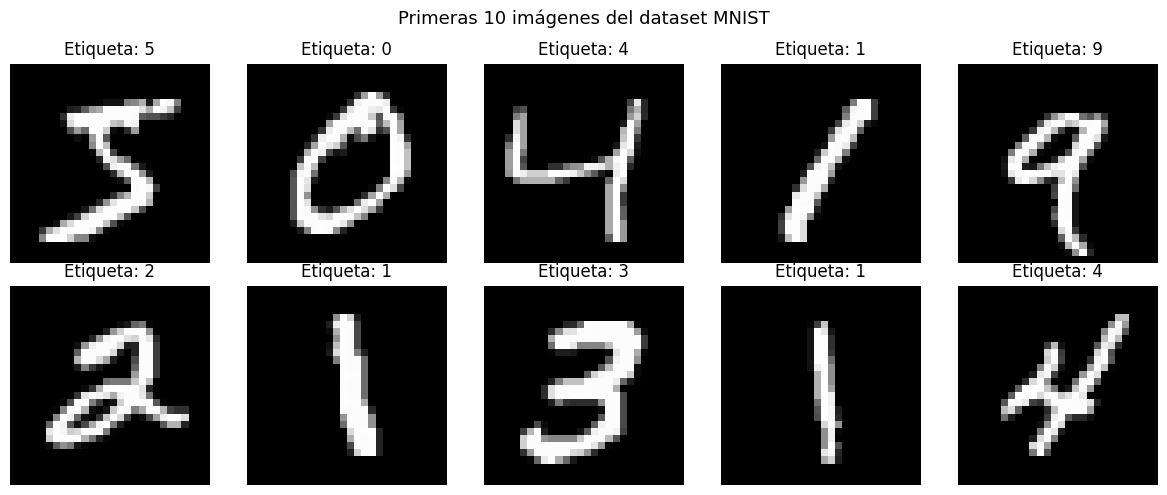


Tras preprocesamiento:
  X_train: (60000, 784) | y_train: (60000, 10)
  X_test:  (10000, 784)  | y_test:  (10000, 10)


Model: "clasificador_mnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta (Dense)                  │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando clasificador MNIST...
Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8887 - loss: 0.4059 - val_accuracy: 0.9405 - val_loss: 0.2118
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9473 - loss: 0.1860 - val_accuracy: 0.9535 - val_loss: 0.1539
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9619 - loss: 0.1359 - val_accuracy: 0.9617 - val_loss: 0.1279
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9699 - loss: 0.1070 - val_accuracy: 0.9678 - val_loss: 0.1115
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9748 - loss: 0.0883 - val_accuracy: 0.9695 - val_loss: 0.1024
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9791 - loss: 0.0739 - val_accuracy: 0.9749 - val_loss: 0.0857
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9825 - loss: 0.0619 - val_accuracy: 0.9753 - val_loss: 0.0821
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9848

In [ ]:
# ─────────────────────────────────────────────────────────
# SECCIÓN 3: Clasificación de dígitos manuscritos con MNIST
# ─────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ── 1. Carga del dataset MNIST ──
# Descarga automática desde los servidores de TensorFlow
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"Forma original — X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Forma original — X_test:  {X_test.shape},  y_test:  {y_test.shape}")

# ── Visualizar algunas muestras del dataset ──
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f"Etiqueta: {y_train[i]}")
    ax.axis('off')
plt.suptitle("Primeras 10 imágenes del dataset MNIST", fontsize=13)
plt.tight_layout()
plt.show()

# ── 2. Preprocesamiento ──

# Aplanar: (60000, 28, 28) → (60000, 784)
# Normalizar: valores de [0, 255] a [0.0, 1.0]
X_train = X_train.reshape((X_train.shape[0], 28 * 28)).astype('float32') / 255
X_test  = X_test.reshape( (X_test.shape[0],  28 * 28)).astype('float32') / 255

# One-hot encoding: entero → vector de 10 posiciones
# Ejemplo: 3 → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
y_train = to_categorical(y_train, num_classes=10)
y_test  = to_categorical(y_test,  num_classes=10)

print(f"\nTras preprocesamiento:")
print(f"  X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"  X_test:  {X_test.shape}  | y_test:  {y_test.shape}")

# ── 3. Definición del modelo ──
model_mnist = Sequential(name="clasificador_mnist")

# Capa oculta: 128 neuronas con ReLU
# input_shape=(784,) porque cada imagen tiene 784 píxeles aplanados
model_mnist.add(Dense(128, input_shape=(28 * 28,), activation='relu', name="oculta"))

# Capa de salida: 10 neuronas (una por dígito 0-9), activación Softmax
# Softmax convierte la salida en probabilidades que suman 1
model_mnist.add(Dense(10, activation='softmax', name="salida"))

# ── 4. Compilación ──
# categorical_crossentropy: pérdida para clasificación multiclase con one-hot
model_mnist.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_mnist.summary()

# ── 5. Entrenamiento ──
# epochs=10: 10 pasadas completas sobre los datos de entrenamiento
# batch_size=200: actualiza los pesos cada 200 muestras
# validation_data: evalúa en el test set al final de cada época
print("\nEntrenando clasificador MNIST...")
history_mnist = model_mnist.fit(
    X_train, y_train,
    epochs=10,
    batch_size=200,
    validation_data=(X_test, y_test),
    verbose=1
)

# ── 6. Evaluación final ──
test_loss, test_acc = model_mnist.evaluate(X_test, y_test, verbose=0)
print(f"\n📊 Evaluación en test set:")
print(f"   Pérdida  : {test_loss:.4f}")
print(f"   Precisión: {test_acc:.4f} ({test_acc*100:.2f}%)")

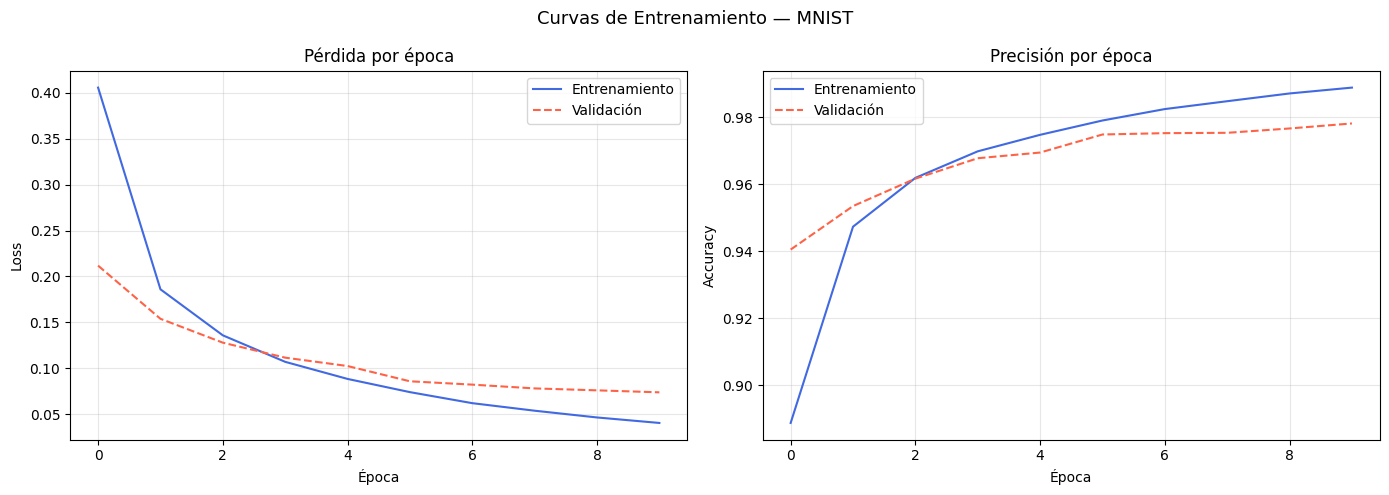

In [6]:
# ─────────────────────────────────────────────────────────
# Visualización de curvas de entrenamiento
# ─────────────────────────────────────────────────────────

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de pérdida
ax1.plot(history_mnist.history['loss'],     label='Entrenamiento', color='royalblue')
ax1.plot(history_mnist.history['val_loss'], label='Validación',    color='tomato', linestyle='--')
ax1.set_title('Pérdida por época')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfica de precisión
ax2.plot(history_mnist.history['accuracy'],     label='Entrenamiento', color='royalblue')
ax2.plot(history_mnist.history['val_accuracy'], label='Validación',    color='tomato', linestyle='--')
ax2.set_title('Precisión por época')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Curvas de Entrenamiento — MNIST', fontsize=13)
plt.tight_layout()
plt.show()

---
# Sección 4 — Ajuste de Hiperparámetros y Evaluación (20 min)

## Concepto

Los **hiperparámetros** controlan el proceso de entrenamiento (no se aprenden del dato):

| Hiperparámetro | Efecto si es muy alto | Efecto si es muy bajo |
|----------------|----------------------|----------------------|
| Tasa de aprendizaje | El modelo diverge (no converge) | Entrenamiento muy lento |
| N° de épocas | Sobreajuste (overfitting) | Modelo subentrenado |
| Batch size | Menos actualizaciones por época | Más ruido en la actualización |

### Learning Rate Scheduler
Un **scheduler** reduce la tasa de aprendizaje automáticamente cuando el modelo deja de mejorar → evita oscilaciones al converger.

> **🎯 Reto:** Implementar un `ReduceLROnPlateau` scheduler y comparar la convergencia.


Entrenando con lr = 0.01 ...
  → Precisión validación final: 97.32%

Entrenando con lr = 0.001 ...
  → Precisión validación final: 97.20%

Entrenando con lr = 0.0001 ...
  → Precisión validación final: 92.55%


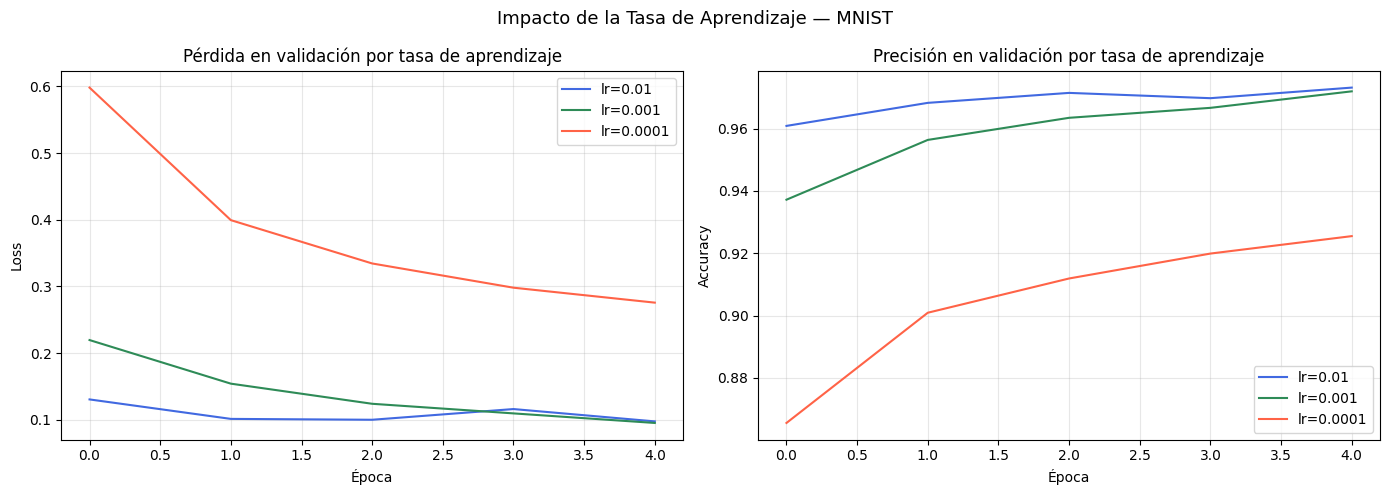

In [ ]:
# ─────────────────────────────────────────────────────────
# SECCIÓN 4: Comparación de tasas de aprendizaje
# ─────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# ── Preparar datos MNIST (reutilizando el preprocesamiento anterior) ──
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()
X_tr = X_train_raw.reshape(-1, 784).astype('float32') / 255
X_te = X_test_raw.reshape(-1,  784).astype('float32') / 255
y_tr = to_categorical(y_train_raw, 10)
y_te = to_categorical(y_test_raw,  10)


def build_model(learning_rate):
    """
    Construye y compila un modelo MLP idéntico variando solo la tasa de aprendizaje.
    Permite comparar el efecto de este hiperparámetro de forma aislada.
    
    Args:
        learning_rate (float): tasa de aprendizaje para el optimizador Adam
    Returns:
        model: modelo Keras compilado
    """
    model = Sequential([
        Dense(128, input_shape=(784,), activation='relu'),
        Dense(10,  activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# ── Experimento: comparar 3 tasas de aprendizaje ──
# Valores recomendados para Adam: rango típico 1e-4 a 1e-2
learning_rates = [0.01, 0.001, 0.0001]
resultados = {}

for lr in learning_rates:
    print(f"\nEntrenando con lr = {lr} ...")
    model_lr = build_model(lr)
    
    # 5 épocas para comparación rápida
    hist = model_lr.fit(
        X_tr, y_tr,
        epochs=5,
        batch_size=200,
        validation_data=(X_te, y_te),
        verbose=0
    )
    resultados[lr] = hist
    val_acc = hist.history['val_accuracy'][-1]
    print(f"  → Precisión validación final: {val_acc*100:.2f}%")

# ── Visualización comparativa ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores = ['royalblue', 'seagreen', 'tomato']

for (lr, hist), color in zip(resultados.items(), colores):
    axes[0].plot(hist.history['val_loss'],     label=f'lr={lr}', color=color)
    axes[1].plot(hist.history['val_accuracy'], label=f'lr={lr}', color=color)

axes[0].set_title('Pérdida en validación por tasa de aprendizaje')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Precisión en validación por tasa de aprendizaje')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Impacto de la Tasa de Aprendizaje — MNIST', fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
# ══════════════════════════════════════════════════════════
# 🎯 RETO: Implementar ReduceLROnPlateau
# El scheduler reduce la lr cuando val_loss no mejora en N épocas
# ══════════════════════════════════════════════════════════

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import matplotlib.pyplot as plt

# Construir modelo con lr inicial moderada
model_sched = Sequential([
    Dense(128, input_shape=(784,), activation='relu'),
    Dense(10,  activation='softmax')
])
model_sched.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ── Callbacks ──

# ReduceLROnPlateau: si val_loss no mejora en 'patience' épocas,
# multiplica lr por 'factor' (la reduce)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,          # nueva lr = lr * 0.5
    patience=2,          # espera 2 épocas sin mejora antes de reducir
    min_lr=1e-6,         # lr mínima posible
    verbose=1
)

# EarlyStopping: detiene el entrenamiento si val_loss no mejora en N épocas
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,  # recupera los mejores pesos encontrados
    verbose=1
)

print("Entrenando con ReduceLROnPlateau + EarlyStopping...")
hist_sched = model_sched.fit(
    X_tr, y_tr,
    epochs=20,
    batch_size=200,
    validation_data=(X_te, y_te),
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

# Resultados
test_loss, test_acc = model_sched.evaluate(X_te, y_te, verbose=0)
print(f"\n📊 Resultado final con scheduler:")
print(f"   Pérdida  : {test_loss:.4f}")
print(f"   Precisión: {test_acc*100:.2f}%")

Entrenando con ReduceLROnPlateau + EarlyStopping...
Epoch 1/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9276 - loss: 0.2364 - val_accuracy: 0.9651 - val_loss: 0.1102 - learning_rate: 0.0100
Epoch 2/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9673 - loss: 0.1054 - val_accuracy: 0.9659 - val_loss: 0.1159 - learning_rate: 0.0100
Epoch 3/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9757 - loss: 0.0783 - val_accuracy: 0.9702 - val_loss: 0.1016 - learning_rate: 0.0100
Epoch 4/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9808 - loss: 0.0611 - val_accuracy: 0.9717 - val_loss: 0.1011 - learning_rate: 0.0100
Epoch 5/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9814 - loss: 0.0588 - val_accuracy: 0.9713 - val_loss: 0.1088 - learning_rate: 0.0100
Epoch 6/20
290/300 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9851 - loss: 0.0453
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
300/300 ━━━━━━━━━━━━━━━━━━━

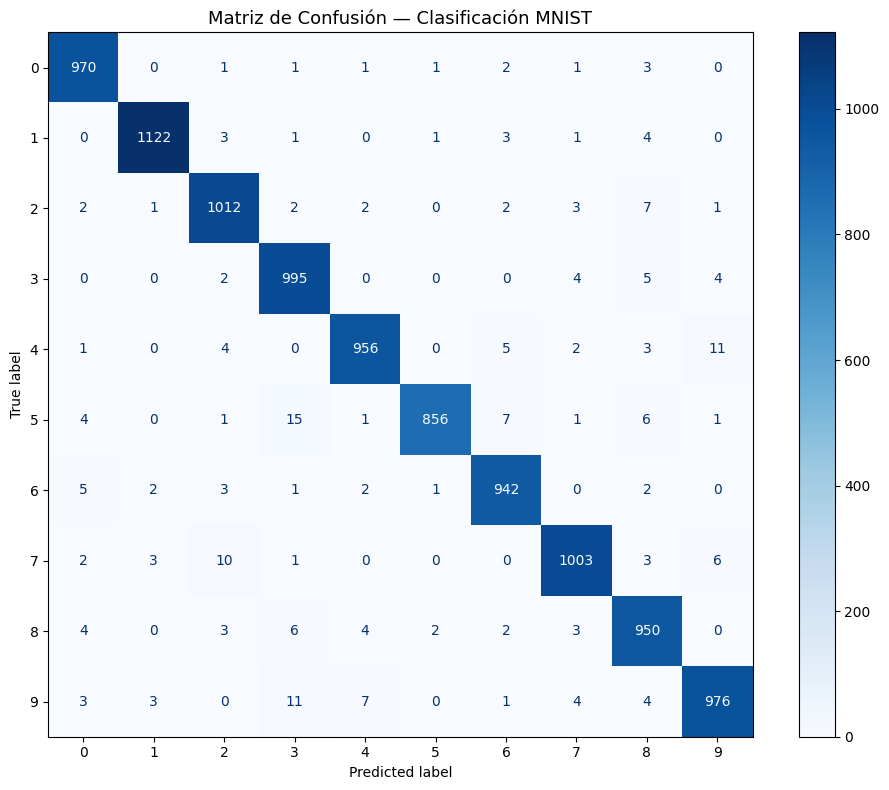


Precisión por dígito:
  Dígito 0: 99.0%
  Dígito 1: 98.9%
  Dígito 2: 98.1%
  Dígito 3: 98.5%
  Dígito 4: 97.4%
  Dígito 5: 96.0%
  Dígito 6: 98.3%
  Dígito 7: 97.6%
  Dígito 8: 97.5%
  Dígito 9: 96.7%


In [9]:
# ─────────────────────────────────────────────────────────
# Matriz de confusión del modelo MNIST
# Muestra qué dígitos confunde más el modelo
# ─────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Obtener predicciones en el test set
y_pred_proba = model_mnist.predict(X_te, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)  # índice con mayor probabilidad
y_true = np.argmax(y_te, axis=1)          # índice real (des-hace one-hot)

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Matriz de Confusión — Clasificación MNIST', fontsize=13)
plt.tight_layout()
plt.show()

# Precisión por clase
print("\nPrecisión por dígito:")
for i in range(10):
    clase_acc = cm[i, i] / cm[i].sum()
    print(f"  Dígito {i}: {clase_acc*100:.1f}%")

---
# ✅ Conclusiones del Laboratorio

En este laboratorio exploramos los fundamentos de las redes neuronales artificiales:

| Concepto | Lo que aprendimos |
|----------|------------------|
| **Perceptrón** | Unidad básica con pesos, sesgo y función de activación escalón |
| **MLP** | Capas ocultas con ReLU permiten resolver problemas no lineales |
| **MNIST** | Preprocesamiento (aplanar, normalizar, one-hot) es clave para el rendimiento |
| **Hiperparámetros** | La tasa de aprendizaje impacta directamente la convergencia |
| **Scheduler** | `ReduceLROnPlateau` estabiliza el entrenamiento automáticamente |

---
## Referencias

1. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.
2. Chollet, F. (2018). *Deep Learning with Python*. Manning Publications.
3. Documentación TensorFlow: https://www.tensorflow.org/learn
4. Dataset MNIST: https://www.tensorflow.org/datasets/catalog/mnist